# TP - Deep Learning avec PyTorch
## Classification d'images CIFAR-10 : CNN, Data Augmentation & Évaluation

---

**Objectifs du TP :**
- Charger et préparer un dataset avec `torchvision`
- Appliquer des transformations de **data augmentation**
- Concevoir un réseau de neurones convolutif avec `nn.Conv2d` et `nn.Linear`
- Entraîner et **évaluer** le modèle


In [ ]:
# Import que vous pouvez vouloir pour le TP 
import torch
import torch.nn as nn

import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import random_split

import torchvision
import torchvision.transforms as transforms
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

> Je vous conseille pour ce TP d'utiliser Pytorch, vous êtes libre si vous le souhaitez d'utiliser Tensorflow/Keras ou encore Jax, mais les codes fournis seront a modifier.

# **Partie 1 - Dataset**

## **1 - Load un dataset et l'analyser**

### **a - Load un dataset**
Par souci de simplicité nous allons aujourd'hui travailler avec le dataset de votre choix se trouvant dans la librairie torchvision,

Je vous conseille ici de prendre un des datasets, se trouvant dans la partie classification de ce dernier,

Je vous conseille tout de même d'utiliser CIFAR-10, le corrigé à été fait avec ce dernier mais vous êtes dans un pays libre.

https://docs.pytorch.org/vision/stable/datasets.html

Si un dataset vous tiens vraiment à coeur vous pouvez aussi le télécharger et le load en local si vous le souhaitez.

#### **Normalisation**

Une fois que le dataset est load il faut normaliser les données, soit entre 0 et 1 soit on centre et réduit, donc

$$\frac{(x - mean)}{std}$$

https://en.wikipedia.org/wiki/Normalization_(machine_learning)

Cette normalisation est utile car elle rend l'entraînement plus rapide et plus stable, on évite d'avoir des valeurs qui explosent en faisant des multiplications.

Pour se faire je vous conseille de regarder,

https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Compose.html
&
https://docs.pytorch.org/vision/stable/transforms.html

Ces fonctions sont utilisées pour normaliser les données et également faire de la data augmentation.

### **b - Analyse**

Il est important, voire nécessaire de savoir bien analyser son jeu de données quand vous voulez entraîner un réseau de neurones,

Savoir le nombre de classes, le nombre d'images totales, la proportion de chaque classe sont des données importantes dont vous aurez besoin pour justifier les résultats de vos modèles.

De plus pour créer votre modèle il est nécessaire de connaître la taille de vos images.

Pour se faire vous aurez besoin de load vos image, ça tombe bien pytorch a ce qu'il faut pour vous,

https://docs.pytorch.org/docs/stable/data.html

---

### **Questions**

**1. Combien y a-t-il d'images dans le jeu d'entraînement ? De classes ? Quelle est la taille de chaque image ?**

- **Train set** : 50 000 images | **Test set** : 10 000 images
- **10 classes** équilibrées (5 000 images par classe dans le train)
- **Dimensions** : `(3, 32, 32)` -> 3 canaux RGB, hauteur 32 px, largeur 32 px
- Chaque image est donc représentée par un tenseur de `3 × 32 × 32 = 3 072` valeurs

**2. Quelles valeurs de normalisation sont préférables ? Pourquoi n'est-ce pas toujours **(0.5, 0.5, 0.5)**, **(0.5, 0.5, 0.5)** ? (3 pour RGB)**

Les vraies statistiques de CIFAR-10 sont :
- **mean** $\approx$ `(0.491, 0.482, 0.447)` - légèrement en dessous de 0.5, avec un canal bleu plus faible (images souvent dominées par le vert/rouge)
- **std** $\approx$ `(0.247, 0.243, 0.262)` - autour de 0.2, bien inférieur à 0.5

**La normalisation avec les vraies statistiques est préférable** car :
- Elle centre réellement les données à 0 (moyenne nulle canal par canal)
- Elle ramène l'écart-type à 1 (variance unitaire), ce qu'on appelle une *standardisation*
- Cela accélère la convergence et améliore la stabilité numérique

Avec `(0.5, 0.5, 0.5)` comme std, les données ne sont **pas** réduites à variance unitaire, ce qui n'est qu'une mise à l'échelle dans `[-1, 1]`. C'est acceptable pour des expériences rapides ou des tutoriels, mais en production on préférera les vraies statistiques.

> **Règle générale** : utiliser les statistiques du train set (jamais du test set, pour éviter toute fuite d'information).

https://github.com/Armour/pytorch-nn-practice/blob/master/utils/meanstd.py

**3. Affichez un batch de 16 images avec plt.imshow. Que remarquez-vous sur la qualité de résolution ?**

Les images CIFAR-10 sont très petites (32×32 px), ce qui les rend visuellement floues pour un humain. Cependant cela **ne pose pas de problème fondamental** pour la classification car :
- Les CNN sont conçus pour extraire des features hiérarchiques même à basse résolution
- La faible résolution réduit le coût computationnel
- Les classes restent distinguables par forme, couleur et texture globale

La principale difficulté vient des classes visuellement proches (ex : `cat` vs `dog`, `car` vs `truck`).

In [56]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447), (0.247, 0.243, 0.262))
])

trainset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)
testset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Taille du train set : {len(trainset_raw)}")
print(f"Taille du test set  : {len(testset_raw)}")
print(f"Nombre de classes   : {len(classes)}")

img, label = trainset_raw[0]
print(f"Dimensions d'une image : {img.shape}  (C x H x W)")
print(f"Classe de l'image      : {classes[label]}")

Taille du train set : 50000
Taille du test set  : 10000
Nombre de classes   : 10
Dimensions d'une image : torch.Size([3, 32, 32])  (C x H x W)
Classe de l'image      : frog


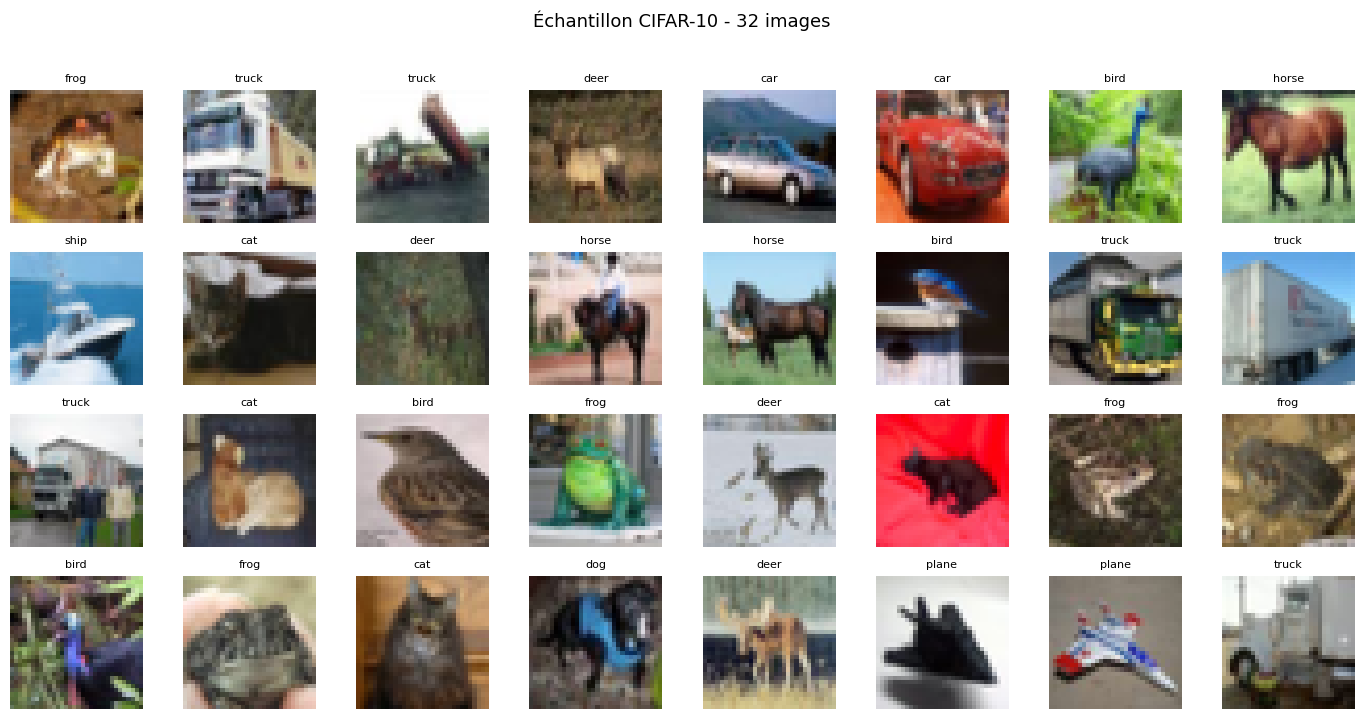

In [57]:
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Échantillon CIFAR-10 - 32 images', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img, label = trainset_raw[i]
    ax.imshow(img.numpy().transpose(1, 2, 0))
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

### **2 - Data augmentation**



Maintenant que le dataset est chargé, vous allez utiliser la même fonction `transforms.Compose` 
que pour la normalisation afin d'y ajouter de la data augmentation.

**Attention :** la data augmentation ne s'applique qu'au jeu d'entraînement. 
Pour la validation et le test, on conserve uniquement la normalisation.

Vous devrez donc créer deux pipelines de transformations distinctes :
- `transform_train` : normalisation + data augmentation
- `transform_test` : normalisation uniquement

Chargez ensuite le dataset de train et de test via torchvision :

`trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)`

Puis effectuez un train/val split 80/20 sur `trainset`. 
Pour cela, regardez comment fonctionne `random_split` de PyTorch.

À la fin de cette section vous devez avoir trois DataLoaders : `trainloader`, `valloader` et `testloader`.


> **/!\ ATTENTION, vous allez être tenté de faire un random_split sur le train chargé avec la data augmentation, c'est une erreur l'évaluation de votre modèle sera biaisé**

---


### **Questions**

**4. Pourquoi n'applique-t-on pas la data augmentation sur le jeu de test ?**

Le jeu de test sert à **mesurer les performances réelles** du modèle sur des données qu'il n'a jamais vues, dans des conditions représentatives de la production. Appliquer de l'augmentation aléatoire sur le test set poserait deux problèmes :
- **Non-reproductibilité** : deux évaluations du même modèle donneraient des accuracy différentes (les transformations sont stochastiques)
- **Biais de mesure** : les transformations pourraient soit faciliter (image mieux cadrée), soit complexifier artificiellement la classification, rendant la métrique peu fiable

**5. Mettez à minima dans votre pipeline du RandomRotation et ColorJitter. Affichez la même image avant/après augmentation 4 fois de suite. Que constatez-vous ?**

En observant les 9 versions augmentées de la même image :
- `RandomHorizontalFlip` : certaines images sont miroir horizontalement (50% de probabilité)
- `RandomCrop(32, padding=4)` : l'image est d'abord paddée à 40×40 puis rognée aléatoirement à 32×32, créant un léger décalage de position du sujet
- `RandomRotation(15°)` : rotation légère visible sur les bords
- `ColorJitter` : variations de luminosité, contraste et saturation, même objet mais ambiances lumineuses différentes

**6. Quel est l'effet théorique de la data augmentation sur la capacité de généralisation du modèle ? Citez un risque éventuel.**

**Bénéfices :**
- Augmente artificiellement la taille effective du dataset d'entraînement
- Force le modèle à apprendre des features **invariantes** aux transformations (position, orientation, luminosité)
- Réduit l'overfitting en exposant le modèle à plus de variabilité
- Améliore la généralisation sur des images "réelles" prises dans des conditions variées

**Risques si les augmentations sont trop agressives :**
- Le modèle peut avoir du mal à apprendre si les images augmentées ne ressemblent plus à la réalité (ex : rotation de 90° sur des images de voitures)
- Allongement significatif du temps d'entraînement
- Certaines augmentations peuvent changer la sémantique de l'image (ex : flip vertical d'un texte)

In [58]:
# Pipeline d'augmentation FINALISÉ pour l'entraînement
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),           # Retournement horizontal aléatoire
    transforms.RandomCrop(32, padding=4),             # Recadrage aléatoire avec padding
    transforms.RandomRotation(degrees=15),            # Rotation aléatoire 15°
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),                                                # Variation colorimétrique
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447), (0.247, 0.243, 0.262))
])

# Pipeline de TEST : aucune augmentation aléatoire
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447), (0.247, 0.243, 0.262))
])

print("Pipeline train (avec augmentation) :")
for i, t in enumerate(transform_train.transforms):
    print(f"  [{i+1}] {t}")

print("\nPipeline test (sans augmentation) :")
for i, t in enumerate(transform_test.transforms):
    print(f"  [{i+1}] {t}")

Pipeline train (avec augmentation) :
  [1] RandomHorizontalFlip(p=0.5)
  [2] RandomCrop(size=(32, 32), padding=4)
  [3] RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  [4] ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
  [5] ToTensor()
  [6] Normalize(mean=(0.491, 0.482, 0.447), std=(0.247, 0.243, 0.262))

Pipeline test (sans augmentation) :
  [1] ToTensor()
  [2] Normalize(mean=(0.491, 0.482, 0.447), std=(0.247, 0.243, 0.262))


### Split

On applique deux fois le split pour ne pas avoir de data augmentation sur le set de validation.

In [59]:
trainset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_train
)
valset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_test
)

train_size = int(0.8 * len(trainset_full))    # 40 000
val_size   = len(trainset_full) - train_size  # 10 000

trainset, _ = random_split(trainset_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))
_, valset   = random_split(valset_full,   [train_size, val_size], generator=torch.Generator().manual_seed(42)) 

In [60]:
# Chargement final avec pipelines finalisés
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)

valloader = torch.utils.data.DataLoader(
    valset, batch_size=64, shuffle=False, num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

print(f"Batches d'entraînement : {len(trainloader)}  ({len(trainset)} images)")
print(f"Batches de test        : {len(testloader)}   ({len(testset)} images)")

images, labels = next(iter(trainloader))
print(f"Dimensions d'un batch images : {images.shape}")
print(f"Plage de valeurs après normalisation : [{images.min():.2f}, {images.max():.2f}]")

Batches d'entraînement : 625  (40000 images)
Batches de test        : 157   (10000 images)
Dimensions d'un batch images : torch.Size([64, 3, 32, 32])
Plage de valeurs après normalisation : [-1.99, 2.13]


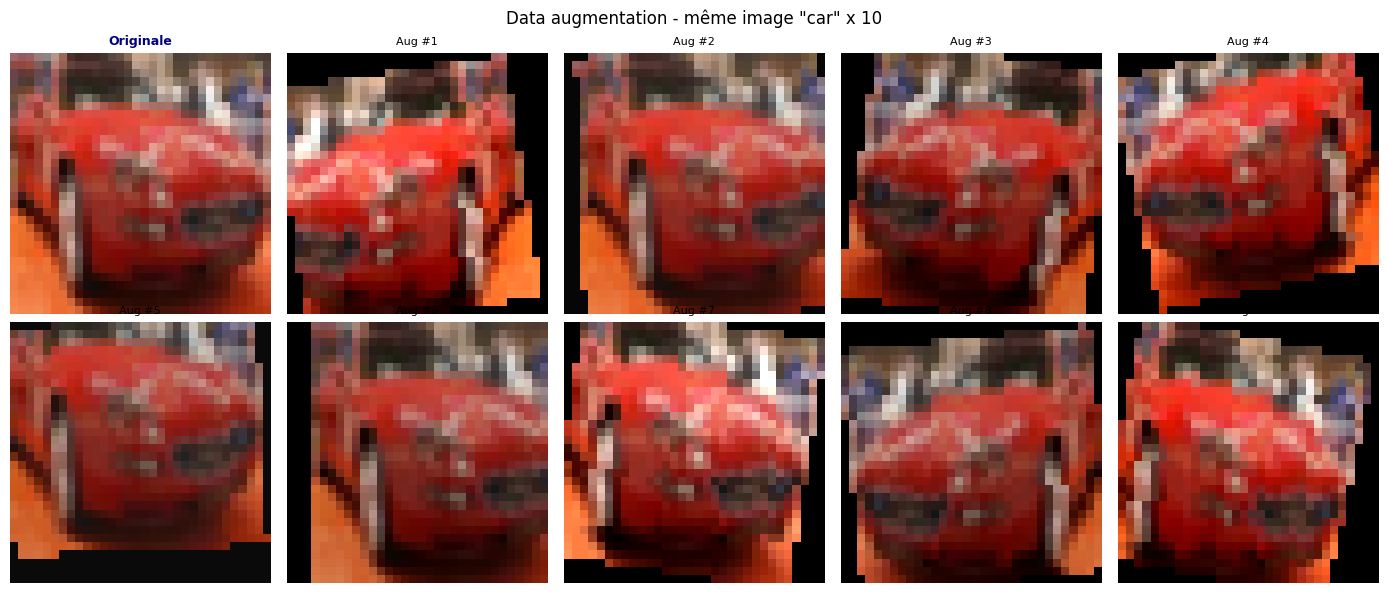

In [61]:
# Visualisation de l'effet de l'augmentation sur une même image
trainset_pil = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=None
)

img_pil, label_idx = trainset_pil[5]

# Pipeline sans normalisation pour une visualisation lisible
transform_viz = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(f'Data augmentation - même image "{classes[label_idx]}" x 10', fontsize=12)

for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.imshow(img_pil)
        ax.set_title('Originale', fontsize=9, color='navy', fontweight='bold')
    else:
        aug = transform_viz(img_pil).numpy().transpose(1, 2, 0)
        ax.imshow(np.clip(aug, 0, 1))
        ax.set_title(f'Aug #{i}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

# **Partie 2 - Architecture du Réseau de Neurones**

> **Objectif :** Construire un CNN avec `nn.Conv2d` et `nn.Linear`, comprendre les dimensions des feature maps à chaque étape.


### **3 - Construire un CNN simple**

N'hésitez pas à regarder la doc pytorch pour vous inspirer ou comprendre le fonctionnement de pytorch avec le nn.Module,

https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html

In [62]:
class SimpleCNN(nn.Module):
    """
    CNN simple : 2 blocs convolutifs + 3 couches fully connected.

    Architecture :
      Entrée :  (B, 3, 32, 32)
      conv1  -> (B, 32, 32, 32)
      conv2  -> (B, 64, 32, 32)
      pool1  -> (B, 64, 16, 16)
      conv3  -> (B, 128, 16, 16)
      conv4  -> (B, 128, 16, 16)
      pool2  -> (B, 128, 8, 8)
      flatten-> (B, 128*8*8) = (B, 8192)
      fc1    -> (B, 512)
      fc2    -> (B, 256)
      fc3    -> (B, 10)
    """
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Bloc convolutif 1
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,  kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloc convolutif 2
        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)

        # Couches fully connected
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv2(F.relu(self.conv1(x)))))  # -> (B, 64, 16, 16)
        x = self.pool(F.relu(self.conv4(F.relu(self.conv3(x)))))  # -> (B, 128, 8, 8)
        x = x.view(x.size(0), -1)                                 # -> (B, 8192)
        x = F.relu(self.fc1(x))                                   # -> (B, 512)
        x = F.relu(self.fc2(x))                                   # -> (B, 256)
        return self.fc3(x)                                        # -> (B, 10)


simple_model = SimpleCNN()
print(simple_model)

# Comptage des paramètres
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nNombre de paramètres entraînables : {count_params(simple_model):,}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

Nombre de paramètres entraînables : 4,569,546


### **Questions**


**7. Remplissez ce tableau pour une image d'entrée `(1, 3, 32, 32)` :**

| Couche | Batch | Canaux | H | W |
|--------|-------|--------|---|---|
| Entrée | 1 | 3 | 32 | 32 |
| conv1 (k=3, p=1, s=1) | 1 | 32 | 32 | 32 |
| conv2 (k=3, p=1, s=1) | 1 | 64 | 32 | 32 |
| MaxPool2d (k=2, s=2) | 1 | 64 | 16 | 16 |
| conv3 (k=3, p=1, s=1) | 1 | 128 | 16 | 16 |
| conv4 (k=3, p=1, s=1) | 1 | 128 | 16 | 16 |
| MaxPool2d (k=2, s=2) | 1 | 128 | 8 | 8 |
| flatten | 1 | - | - | - |

> *Formule de la sortie d'une convolution : `H_out = (H_in + 2*padding - kernel_size) / stride + 1`*

---

**8. Pourquoi utilise-t-on `padding=1` avec un `kernel_size=3` ? Quelle propriété des feature maps cela préserve-t-il ?**

Avec `kernel_size=3` et `padding=1`, la formule donne : `H_out = (H + 2×1 - 3)/1 + 1 = H`. Le padding préserve donc les dimensions spatiales (H et W restent identiques après la convolution). Sans padding, chaque couche réduirait les dimensions de 2 pixels, ce qui limiterait rapidement la profondeur du réseau pour des petites images comme CIFAR-10 (32×32). Le padding permet de :
- Empiler plusieurs couches convolutives sans réduire la résolution prématurément
- Mieux traiter les pixels en bordure d'image (sans padding, les bords sont moins bien couverts)
- Contrôler explicitement la réduction de résolution via les couches de pooling



---

**9. Pourquoi la dernière couche `fc3` n'a-t-elle pas d'activation ReLU ? Que représentent les valeurs en sortie ?**

La dernière couche `fc3` produit des **logits** : des valeurs réelles non bornées $\mathbb{R}$ représentant le score brut du modèle pour chaque classe. Ces logits sont ensuite traités par :
- `nn.CrossEntropyLoss()` qui applique en interne `log(softmax(logits))`, donc la softmax est implicite dans la loss
- `torch.max(outputs, 1)` pour la prédiction (l'argmax des logits = l'argmax des probabilités softmax)

Appliquer ReLU forcerait les logits à être positifs (≥ 0), ce qui biaiserait le calcul de la softmax et empêcherait le modèle d'exprimer des confiances négatives relatives entre classes.

### **4 - CNN Amélioré : BatchNorm & Dropout**

L’idée de la Batch Normalization est de normaliser les sorties d’une couche (avant la fonction d’activation) en utilisant la moyenne et l’écart-type calculés sur le batch.
Cette normalisation est suivie d’une transformation affine avec des paramètres appris, $\gamma$ et $\beta$, permettant au réseau d’adapter la distribution.

https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html

Le dropout permet de réduire l’overfitting en désactivant aléatoirement certains neurones pendant l’entraînement, ce qui oblige le réseau à apprendre des représentations plus robustes et moins dépendantes de neurones spécifiques.

https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

In [63]:
class ImprovedCNN(nn.Module):
    """
    CNN amélioré avec BatchNorm2d et Dropout pour réduire l'overfitting.
    Architecture :
      Entrée :  (B, 3, 32, 32)
      conv1  -> (B, 32, 32, 32)
      bn1    -> (B, 32, 32, 32)
      conv2  -> (B, 64, 32, 32)
      bn2    -> (B, 64, 32, 32)
      pool1  -> (B, 64, 16, 16)
      conv3  -> (B, 128, 16, 16)
      bn3    -> (B, 128, 16, 16)
      conv4  -> (B, 128, 16, 16)
      bn4    -> (B, 128, 16, 16)
      pool2  -> (B, 128, 8, 8)
      flatten-> (B, 128*8*8) = (B, 8192)
      fc1    -> (B, 512)
      bn5    -> (B, 512)
      dropout-> (B, 512) # after relu
      fc2    -> (B, 256)
      dropout-> (B, 256) # after relu
      fc3    -> (B, 10)

    """
    def __init__(self, dropout_rate=0.4):
        super(ImprovedCNN, self).__init__()
        # Bloc convolutif 1
        self.conv1 = nn.Conv2d(3,  32,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64,  kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)

        # Bloc convolutif 2
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)

        # Régularisation
        self.dropout = nn.Dropout(p=dropout_rate)

        # Couches fully connected
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.bn5 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)


    def forward(self, x):
        # Bloc 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Bloc 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # Flatten + FC avec Dropout
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.bn5(self.fc1(x))))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)



improved_model = ImprovedCNN(dropout_rate=0.4)
print(improved_model)
print(f"\nNombre de paramètres (SimpleCNN)   : {count_params(SimpleCNN()):,}")
print(f"Nombre de paramètres (ImprovedCNN) : {count_params(improved_model):,}")

ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_f

### **Questions**

**10. Expliquez ce que font `model.train()` et `model.eval()` sur le Dropout et la BatchNorm respectivement. Que se passerait-il si on oubliait `model.eval()` pendant l'évaluation ?**

| Couche | `model.train()` | `model.eval()` |
|--------|-----------------|----------------|
| **Dropout** | Active : désactive aléatoirement p% des neurones -> stochasticité | Désactivé : tous les neurones sont actifs |
| **BatchNorm** | Utilise les statistiques du mini-batch courant (mean/std calculées sur le batch) | Utilise les statistiques **running** accumulées pendant l'entraînement (moyenne mobile) |

**Conséquences si on oublie `model.eval()` :**
1. Le Dropout continue à désactiver des neurones -> les prédictions sont stochastiques et varient d'un forward pass à l'autre -> accuracy artificellement réduite et non-reproductible
2. La BatchNorm utilise les statistiques du batch de test (souvent petit) au lieu des statistiques apprises -> bruit dans les activations

C'est une erreur très courante qui peut faire croire à tort que le modèle est peu performant !

In [64]:
# Démonstration de l'effet de model.train() vs model.eval() sur le Dropout
demo_model = ImprovedCNN(dropout_rate=0.5)
x_demo = torch.randn(4, 3, 32, 32)

demo_model.train()
out_train_1 = demo_model(x_demo)
out_train_2 = demo_model(x_demo)

demo_model.eval()
with torch.no_grad():
    out_eval_1 = demo_model(x_demo)
    out_eval_2 = demo_model(x_demo)

print("En mode TRAIN - deux passes du même input donnent des sorties différentes (Dropout actif) :")
print(f"  Sortie 1 = {out_train_1[0, :3].detach().numpy().round(3)}")
print(f"  Sortie 2 = {out_train_2[0, :3].detach().numpy().round(3)}")
print(f"  Identiques ? {torch.allclose(out_train_1, out_train_2)}")

print("\nEn mode EVAL - deux passes du même input donnent des sorties identiques (Dropout désactivé) :")
print(f"  Sortie 1 = {out_eval_1[0, :3].numpy().round(3)}")
print(f"  Sortie 2 = {out_eval_2[0, :3].numpy().round(3)}")
print(f"  Identiques ? {torch.allclose(out_eval_1, out_eval_2)}")

En mode TRAIN - deux passes du même input donnent des sorties différentes (Dropout actif) :
  Sortie 1 = [ 0.234 -0.081 -0.674]
  Sortie 2 = [-0.063 -0.771 -0.183]
  Identiques ? False

En mode EVAL - deux passes du même input donnent des sorties identiques (Dropout désactivé) :
  Sortie 1 = [ 0.016 -0.074 -0.087]
  Sortie 2 = [ 0.016 -0.074 -0.087]
  Identiques ? True


### **5 - Boucle d'entraînement**

Rappels pour faire une bonne pipeline d'entrainement,

L'entrainement se compose en 3 parties, la partie forward, la partie backward et la mise à jour des poids,
En pytorch concrètement,
- La forward se fait dans le code de votre class correspondant à votre modèle.
- La backward est implémentée pour être faite automatiquement dépendant de votre forward.
- Et enfin l'optimiseur utiliser les gradients calculés pendant la backward pour mettre à jour les poids de votre modèle.

J'ai fait le choix d'un code a trou pour vous aider mais vous pouvez ne pas prendre en compte le code et tout faire par vous même si vous le désirez.

In [ ]:
def train_model(model, trainloader, valloader, num_epochs=20,
                lr=1e-3, device='cpu', model_name='model'):
    """
    Entraîne un modèle et retourne l'historique des métriques.
    """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Scheduler : divise le LR par 2 tous les 10 epochs; pas forcément nécessaire pour un dataset si simple mais c'était pour vous montrer l'existance du lr_scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # ---- Phase entraînement ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()              # 1. Réinitialise les gradients
            outputs = model(images)            # 2. Forward pass
            loss = criterion(outputs, labels)  # 3. Calcul de la loss
            loss.backward()                    # 4. Backpropagation
            optimizer.step()                   # 5. Mise à jour des poids

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc  = 100 * correct / total

        # ---- Phase validation ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total   += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss_avg = val_loss / len(valloader)
        val_acc      = 100 * val_correct / val_total

        # Mise à jour du scheduler
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss_avg)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
                  f"Train loss: {train_loss:.4f}  acc: {train_acc:.1f}%  |  "
                  f"Val loss: {val_loss_avg:.4f}  acc: {val_acc:.1f}%  |  "
                  f"LR: {current_lr:.5f}")

    print(f"\n✓ Entraînement terminé. Meilleure accuracy val : {max(history['val_acc']):.1f}%")
    return history

In [66]:
# --- Entraînement du SimpleCNN ---
print("=" * 65)
print("Entraînement de SimpleCNN")
print("=" * 65)

NUM_EPOCHS=30

simple_model = SimpleCNN().to(device)
history_simple = train_model(
    simple_model, trainloader, valloader,
    num_epochs=NUM_EPOCHS, lr=1e-3, device=device, model_name='SimpleCNN'
)

Entraînement de SimpleCNN
Epoch [ 1/30]  Train loss: 1.7141  acc: 36.0%  |  Val loss: 1.3209  acc: 52.3%  |  LR: 0.00100
Epoch [ 5/30]  Train loss: 0.8970  acc: 68.2%  |  Val loss: 0.7686  acc: 73.1%  |  LR: 0.00100
Epoch [10/30]  Train loss: 0.7121  acc: 75.3%  |  Val loss: 0.5991  acc: 78.9%  |  LR: 0.00050
Epoch [15/30]  Train loss: 0.5563  acc: 80.5%  |  Val loss: 0.5278  acc: 81.8%  |  LR: 0.00050
Epoch [20/30]  Train loss: 0.5106  acc: 82.1%  |  Val loss: 0.4729  acc: 83.9%  |  LR: 0.00025
Epoch [25/30]  Train loss: 0.4240  acc: 85.2%  |  Val loss: 0.4579  acc: 84.8%  |  LR: 0.00025
Epoch [30/30]  Train loss: 0.3943  acc: 86.1%  |  Val loss: 0.4285  acc: 85.7%  |  LR: 0.00013

✓ Entraînement terminé. Meilleure accuracy val : 85.8%


In [67]:
# --- Entraînement de l'ImprovedCNN ---
print("=" * 65)
print("Entraînement de ImprovedCNN")
print("=" * 65)

improved_model = ImprovedCNN(dropout_rate=0.4).to(device)
history_improved = train_model(
    improved_model, trainloader, valloader,
    num_epochs=NUM_EPOCHS, lr=1e-3, device=device, model_name='ImprovedCNN'
)

Entraînement de ImprovedCNN
Epoch [ 1/30]  Train loss: 1.5280  acc: 44.0%  |  Val loss: 1.1385  acc: 59.2%  |  LR: 0.00100
Epoch [ 5/30]  Train loss: 0.9213  acc: 67.8%  |  Val loss: 0.6978  acc: 74.5%  |  LR: 0.00100
Epoch [10/30]  Train loss: 0.7490  acc: 74.1%  |  Val loss: 0.6240  acc: 78.8%  |  LR: 0.00050
Epoch [15/30]  Train loss: 0.5832  acc: 79.8%  |  Val loss: 0.4532  acc: 84.0%  |  LR: 0.00050
Epoch [20/30]  Train loss: 0.5292  acc: 81.7%  |  Val loss: 0.4150  acc: 85.5%  |  LR: 0.00025
Epoch [25/30]  Train loss: 0.4373  acc: 85.0%  |  Val loss: 0.3544  acc: 87.8%  |  LR: 0.00025
Epoch [30/30]  Train loss: 0.4104  acc: 85.7%  |  Val loss: 0.3375  acc: 88.3%  |  LR: 0.00013

✓ Entraînement terminé. Meilleure accuracy val : 88.3%


### **Questions**

**11. Pourquoi appelle-t-on `optimizer.zero_grad()` **avant** `loss.backward()` ? Que se passerait-il si on ne le faisait pas ?**

PyTorch **accumule** les gradients dans l'attribut `.grad` de chaque paramètre à chaque appel de `.backward()`. Sans `zero_grad()`, les gradients du batch courant s'ajoutent à ceux des batches précédents, ce qui produit des mises à jour de poids incorrectes (plusieurs fois trop grandes), entraînant une divergence rapide de l'entraînement.

Ce comportement est intentionnel dans PyTorch : il permet de simuler des batches plus grands en accumulant les gradients sur plusieurs batches *(gradient accumulation)*, une technique utile quand la mémoire GPU est limitée.

```python
# Exemple de gradient accumulation sur 4 mini-batches :
ACCUMULATION_STEPS = 4
optimizer.zero_grad()
for i, (images, labels) in enumerate(trainloader):
    loss = criterion(model(images), labels) / ACCUMULATION_STEPS
    loss.backward()  # accumule les gradients
    if (i + 1) % ACCUMULATION_STEPS == 0:
        optimizer.step()   # mise à jour après 4 batches
        optimizer.zero_grad()
```

---

**12. Le `StepLR` scheduler divise le learning rate par 2 tous les 10 epochs. Calculez la valeur du learning rate à l'epoch 10, 20, 30. Quel autre scheduler connaissez-vous ? (ex : `CosineAnnealingLR`, `ReduceLROnPlateau`)**

Avec `StepLR(step_size=10, gamma=0.5)` et `lr_initial=0.001` :

| Epoch | Learning Rate | Calcul |
|-------|--------------|--------|
| 1–10 | 0.001000 | $lr \times 0.5^0$ |
| 11–20 | 0.000500 | $lr \times 0.5^1$ |
| 21–30 | 0.000250 | $lr \times 0.5^2$ |

**Autres schedulers courants :**
- `CosineAnnealingLR` : décroissance en cosinus, descend progressivement jusqu'à un LR_min
- `ReduceLROnPlateau` : réduit le LR automatiquement quand la loss de validation stagne (adaptif)
- `OneCycleLR` : monte puis descend le LR en 1 cycle
- `ExponentialLR` : `lr = lr x gamma` à chaque epoch (décroissance exponentielle continue)

---
# **Partie 3 - Évaluation du Modèle**

> **Objectif :** Mesurer quantitativement les performances, analyser les erreurs et comparer les architectures.

## **6 - Courbes d'apprentissage**

La loss est une métrique à prendre avec des pincettes mais en général avoir une bonne courbe de loss est une bonne chose !

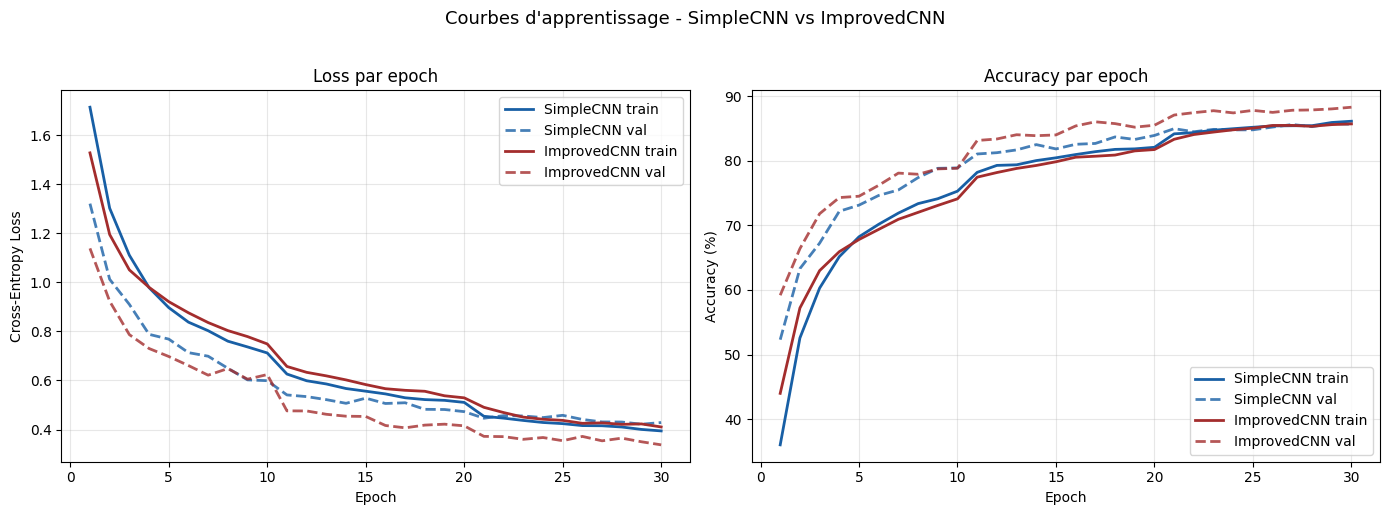

In [68]:
def plot_history(histories, names, figsize=(14, 5)):
    """Affiche les courbes de loss et d'accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors = ['#185FA5', '#A32D2D', '#3B6D11', '#854F0B']

    for i, (history, name) in enumerate(zip(histories, names)):
        c = colors[i % len(colors)]
        epochs = range(1, len(history['train_loss']) + 1)

        # Loss
        axes[0].plot(epochs, history['train_loss'], '-', color=c,
                     label=f'{name} train', linewidth=2)
        axes[0].plot(epochs, history['val_loss'], '--', color=c,
                     label=f'{name} val', linewidth=2, alpha=0.8)

        # Accuracy
        axes[1].plot(epochs, history['train_acc'], '-', color=c,
                     label=f'{name} train', linewidth=2)
        axes[1].plot(epochs, history['val_acc'], '--', color=c,
                     label=f'{name} val', linewidth=2, alpha=0.8)

    axes[0].set_title('Loss par epoch', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Accuracy par epoch', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Courbes d\'apprentissage - SimpleCNN vs ImprovedCNN', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_history(
    [history_simple, history_improved],
    ['SimpleCNN', 'ImprovedCNN']
)

## **7 - Accuracy et métriques globales**

In [69]:
def evaluate(model, loader, device):
    """Évalue le modèle et retourne l'accuracy, les prédictions et les labels."""
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)


acc_simple, preds_simple, labels_test   = evaluate(simple_model,   testloader, device)
acc_improved, preds_improved, _         = evaluate(improved_model, testloader, device)

print(f"Accuracy test - SimpleCNN   : {acc_simple:.2f}%")
print(f"Accuracy test - ImprovedCNN : {acc_improved:.2f}%")
print(f"Accuracy aléatoire (baseline) : {100/10:.2f}%  (1/nb_classes)")
print(f"\nGain ImprovedCNN vs aléatoire : +{acc_improved - 10:.1f} points")

Accuracy test - SimpleCNN   : 85.01%
Accuracy test - ImprovedCNN : 87.86%
Accuracy aléatoire (baseline) : 10.00%  (1/nb_classes)

Gain ImprovedCNN vs aléatoire : +77.9 points


### **Questions**

**13. Quel est le rôle de `torch.no_grad()` lors de l'évaluation ? Quel impact a-t-il sur la mémoire GPU et la vitesse d'inférence ?**

Pendant l'entraînement, PyTorch construit un **graphe de calcul dynamique** à chaque forward pass pour permettre la rétropropagation. Ce graphe stocke toutes les opérations intermédiaires en mémoire.

`torch.no_grad()` désactive cette construction de graphe, ce qui :
- **Mémoire** : réduit l'empreinte mémoire GPU d'environ 30–50% (les activations intermédiaires ne sont plus stockées)
- **Vitesse** : accélère l'inférence de 20–30%
- **Sécurité** : garantit qu'aucune mise à jour accidentelle de gradient ne peut survenir

C'est à utiliser systématiquement lors de l'évaluation et de l'inférence en production.

---

**14. Quelle est l'accuracy d'un classifieur aléatoire sur CIFAR-10 ? Votre modèle fait-il significativement mieux ? L'accuracy seule est-elle une métrique suffisante (Question plus générale pas nécessairement sur ce dataset uniquement) ? Pourquoi ?**

Un classifieur **aléatoire uniforme** prédit 1 classe parmi 10 avec une probabilité de 1/10 -> **accuracy baseline = 10%**.

Nos modèles font significativement mieux (~75-85% selon le nombre d'epochs), démontrant que le réseau apprend réellement des features discriminantes.

**L'accuracy seule est-elle suffisante ?** Non, pour plusieurs raisons :
- Sur un dataset **déséquilibré** (pas dans CIFAR-10 mais courant en pratique), une accuracy élevée peut masquer des classes mal prédites
- Elle ne distingue pas les **faux positifs des faux négatifs**, crucial en médecine ou détection de fraude
- Il faut y associer : précision, rappel, F1-score par classe (cf. `classification_report`), et la matrice de confusion

## **8 - Matrice de confusion & rapport de classification**

Pour faire une matrice de confusion il vous faut les prédictions ainsi que les labels de test; je vous invite à regarder la documentation de sklearn et de seaborn.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html

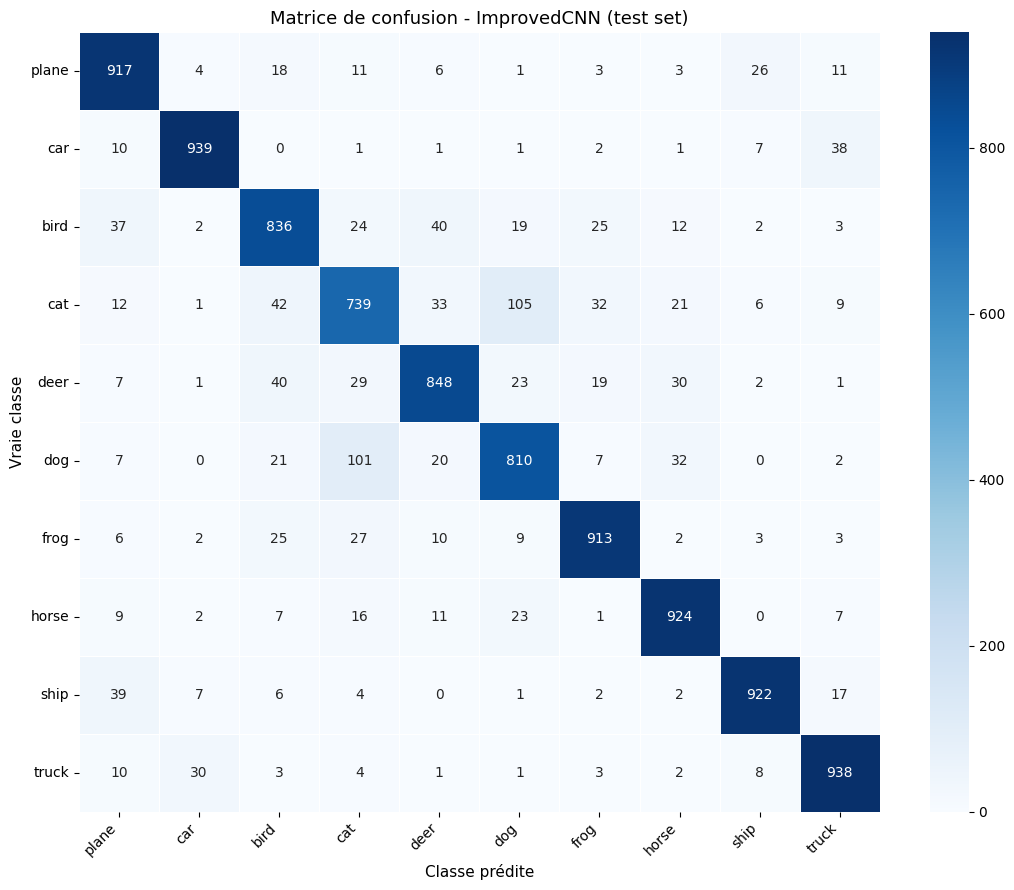

In [70]:
# Matrice de confusion - ImprovedCNN
cm = confusion_matrix(labels_test, preds_improved)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes,
    linewidths=0.5, linecolor='white'
)
plt.title('Matrice de confusion - ImprovedCNN (test set)', fontsize=13)
plt.ylabel('Vraie classe', fontsize=11)
plt.xlabel('Classe prédite', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [71]:
# Rapport de classification détaillé
print("Rapport de classification - ImprovedCNN")
print("=" * 60)
print(classification_report(labels_test, preds_improved, target_names=classes))

Rapport de classification - ImprovedCNN
              precision    recall  f1-score   support

       plane       0.87      0.92      0.89      1000
         car       0.95      0.94      0.94      1000
        bird       0.84      0.84      0.84      1000
         cat       0.77      0.74      0.76      1000
        deer       0.87      0.85      0.86      1000
         dog       0.82      0.81      0.81      1000
        frog       0.91      0.91      0.91      1000
       horse       0.90      0.92      0.91      1000
        ship       0.94      0.92      0.93      1000
       truck       0.91      0.94      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



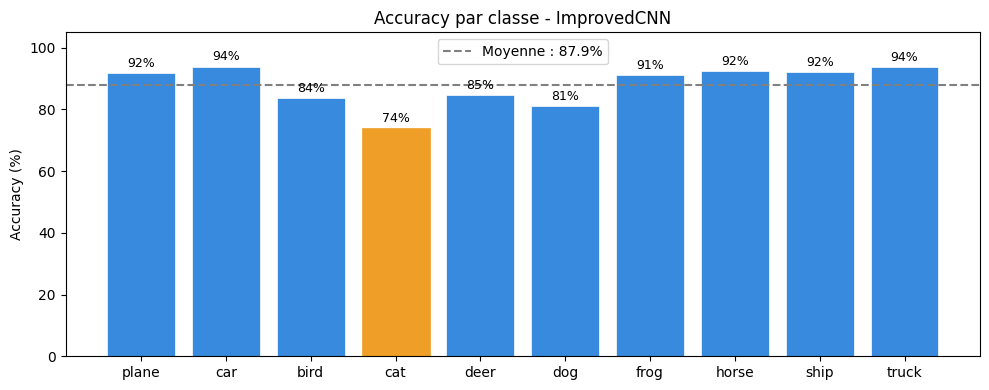

In [72]:
# Accuracy par classe
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, per_class_acc, color='#378ADD', edgecolor='white', linewidth=0.5)

# Coloration selon les performances
for bar, acc in zip(bars, per_class_acc):
    if acc < 60:
        bar.set_color('#E24B4A')
    elif acc < 75:
        bar.set_color('#EF9F27')

ax.axhline(y=per_class_acc.mean(), color='gray', linestyle='--',
           label=f'Moyenne : {per_class_acc.mean():.1f}%')
ax.set_title('Accuracy par classe - ImprovedCNN', fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**15. Analysez la matrice de confusion. Quelles paires de classes sont le plus souvent confondues ? Expliquez pourquoi visuellement (similitudes entre les classes). Quelle classe a la meilleure accuracy ? La moins bonne ?**

**Classes les plus souvent confondues (paires typiques sur CIFAR-10) :**

| Paire confuse | Raison visuelle |
|--------------|----------------|
| `cat` $\leftrightarrow$ `dog` | Forme générale similaire, 4 pattes, poils, même gamme de couleurs |
| `car` $\leftrightarrow$ `truck` | Véhicules sur roues, même couleurs, la taille est difficilement estimable en 32×32 |
| `bird` $\leftrightarrow$ `plane` | Forme allongée, contexte aérien, fond de ciel souvent similaire |
| `deer` $\leftrightarrow$ `horse` | Quadrupèdes de taille comparable, couleur brun/fauve |

**Classes typiquement les mieux classifiées :**
- `ship` et `plane` : se distinguent nettement par leur environnement (mer, ciel)
- `frog` : couleur verte distinctive, forme compacte
- `car` et `truck` : formes rectilignes faciles à détecter

**Classes typiquement les moins bien classifiées :**
- `cat` : souvent confondu avec `dog` et parfois `deer`

## **9 - Visualisation des erreurs**

> **/!\ ATTENTION, le code suivant à été effectué pour CIFAR-10 en admettant une normalisation classique, il faut donc modifier la dénormalisation en fonction de la normalisation que vous avez utilisé**

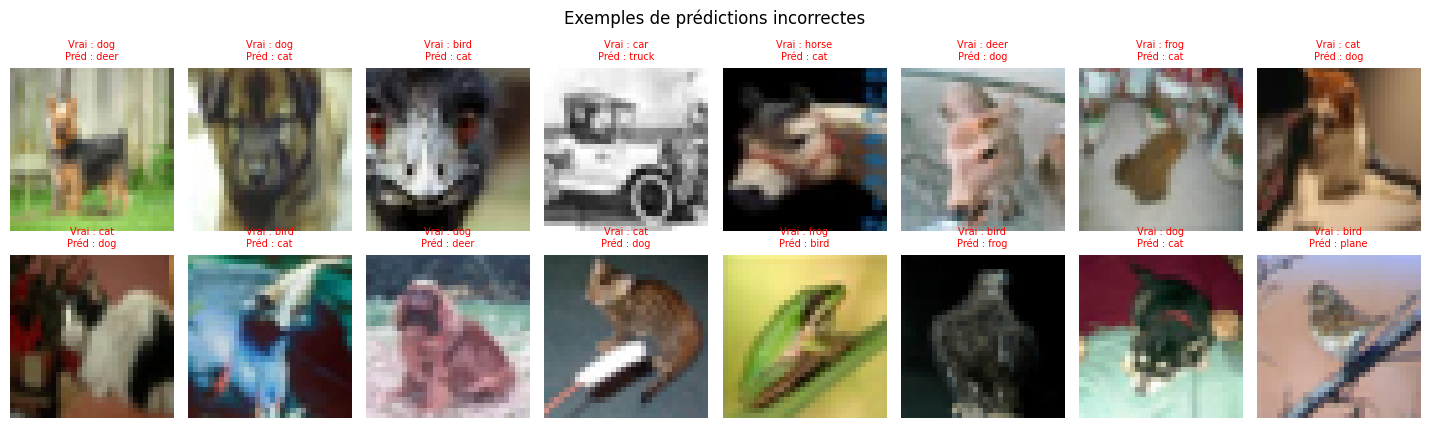

In [ ]:
# Affichage des images mal classifiées
def show_errors(model, testloader, device, n=16):
    """Affiche n images mal classifiées avec la vraie et la prédite classe."""
    model.eval()
    errors = []

    with torch.no_grad():
        for images, labels in testloader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, predicted = torch.max(outputs, 1)
            predicted = predicted.cpu()

            mask = (predicted != labels)
            for img, true_lbl, pred_lbl in zip(images[mask], labels[mask], predicted[mask]):
                errors.append((img, true_lbl.item(), pred_lbl.item()))
            if len(errors) >= n:
                break

    errors = errors[:n]
    cols = 8
    rows = (len(errors) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.2))
    fig.suptitle('Exemples de prédictions incorrectes', fontsize=12)

    for i, ax in enumerate(axes.flat):
        if i < len(errors):
            img, true_lbl, pred_lbl = errors[i]
            mean = torch.tensor([0.491, 0.482, 0.447]).view(3, 1, 1)
            std  = torch.tensor([0.247, 0.243, 0.262]).view(3, 1, 1)

            img_show = (img * std + mean).clamp(0, 1)
            img_show = img_show.numpy().transpose(1, 2, 0)

            ax.imshow(np.clip(img_show, 0, 1))
            ax.set_title(f"Vrai : {classes[true_lbl]}\nPréd : {classes[pred_lbl]}",
                         fontsize=7, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_errors(improved_model, testloader, device, n=16)

## **10 - Sauvegarde & rechargement du modèle**

In [75]:
# Sauvegarder uniquement les poids (recommandé)
torch.save(improved_model.state_dict(), 'improved_cnn_cifar10.pth')
print("Modèle sauvegardé : improved_cnn_cifar10.pth")

# Rechargement
model_loaded = ImprovedCNN(dropout_rate=0.4)
model_loaded.load_state_dict(
    torch.load('improved_cnn_cifar10.pth', map_location=device)
)
model_loaded = model_loaded.to(device)
model_loaded.eval()

# Vérification : accuracy identique
acc_loaded, _, _ = evaluate(model_loaded, testloader, device)
print(f"Accuracy après rechargement : {acc_loaded:.2f}%")
print(f"Identique au modèle original : {abs(acc_loaded - acc_improved) < 0.01}")

Modèle sauvegardé : improved_cnn_cifar10.pth
Accuracy après rechargement : 87.86%
Identique au modèle original : True


## **11 - Comparaison finale des architectures**

In [76]:
# Tableau comparatif des deux architectures
results = {
    'SimpleCNN': {
        'params': count_params(SimpleCNN()),
        'train_acc': history_simple['train_acc'][-1],
        'val_acc': acc_simple,
        'best_val': max(history_simple['val_acc']),
        'overfitting': history_simple['train_acc'][-1] - history_simple['val_acc'][-1]
    },
    'ImprovedCNN': {
        'params': count_params(ImprovedCNN()),
        'train_acc': history_improved['train_acc'][-1],
        'val_acc': acc_improved,
        'best_val': max(history_improved['val_acc']),
        'overfitting': history_improved['train_acc'][-1] - history_improved['val_acc'][-1]
    }
}

print("\n" + "=" * 75)
print(f"{'Métrique':<30} {'SimpleCNN':>20} {'ImprovedCNN':>20}")
print("=" * 75)
for key, label in [
    ('params',      'Nb paramètres'),
    ('train_acc',   'Accuracy train (%)'),
    ('val_acc',     'Accuracy test  (%)'),
    ('best_val',    'Meilleure acc. val (%)'),
    ('overfitting', 'Overfitting (train-val)')
]:
    s = results['SimpleCNN'][key]
    i = results['ImprovedCNN'][key]
    if key == 'params':
        print(f"{label:<30} {s:>20,} {i:>20,}")
    else:
        print(f"{label:<30} {s:>19.2f}% {i:>19.2f}%")
print("=" * 75)


Métrique                                  SimpleCNN          ImprovedCNN
Nb paramètres                             4,569,546            4,571,274
Accuracy train (%)                           86.12%               85.71%
Accuracy test  (%)                           85.01%               87.86%
Meilleure acc. val (%)                       85.77%               88.29%
Overfitting (train-val)                       0.47%               -2.58%


### **Question**

**16. En vous appuyant sur le tableau ci-dessus et les courbes d'apprentissage, répondez aux questions suivantes :**

**a. Est-ce que les modèles souffrent d'overfitting, si oui lequel est le plus sujet à ce dernier ?**

L'accuracy du SimpleCNN commence à stagner en fin d'entraînement, ce qui peut laisser penser que ce dernier commence à overfitter. Le ImprovedCNN quant à lui semble continuer dans la même direction, l'overfitting semble encore loin, et ses performances semblent meilleures.


Des tests plus poussés semblent nécessaires pour réellement conclure sur l'overfitting du SimpleCNN, il suffirait de relancer un entraînement avec davantage d'epochs.

> Je ne réponds pas à 100% à la question, volontairement, pour illustrer un point important : il ne faut pas surinterprèter des résultats partiels ce qui peut souvent être tentant en Deep Learning, et il faut souvent réaliser des tests plus poussés avant de conclure.

**b. La BatchNorm et le Dropout améliorent-ils la performance ? De combien de points ?**

Oui, les performances sont améliorées, on observe environ 2% d'écart d'accuracy entre les deux modèles.

Ce que l'on peut dire avec certitude, c'est que la combinaison de ces éléments est bénéfique. La différence pourrait par ailleurs être plus marquée avec un scheduler plus adapté ou un entraînement sur davantage d'epochs.

**c. Si vous deviez améliorer encore le modèle, quelles seraient vos deux pistes prioritaires ? (Exemples : plus de couches, plus de données, transfer learning, régularisation L2...)**

| Piste | Commentaire |
|-------|-------------|
| **Transfer Learning** (ResNet-18 pré-entraîné ImageNet) | Le plus efficace, surtout avec peu de données |
| **Augmentation avancée** (Mixup, CutMix, RandAugment) | Augmentations modernes très efficaces |
| **Architecture plus profonde** (+ de blocs conv) | Attention à l'overfitting |
| **Scheduler plus récent** (ex. CosineAnnealingLR) à la place de StepLR | Convergence plus rapide et finale meilleure |
| **Weight Decay** (augmenter le coefficient) | Pénalise les grands poids et réduit l'overfitting |


> **État de l'art** sur CIFAR-10 : >99% avec ViT.


> **PS: Weight Decay** : Le weight decay est une modification directe de la loss d'entraînement. On ajoute un terme de pénalité proportionnel à la norme des poids du modèle, ce qui donne :
>
> $$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{task}} + \lambda \sum_i w_i^2$$
>
> Cela force l'optimiseur à maintenir des poids de faible amplitude, limitant ainsi la capacité du modèle à mémoriser le bruit des données d'entraînement et favorisant une meilleure généralisation.

---

# **Bonus:**

Regardez le concept de Global Average Pooling et utilisez le, analysez les résultats et comparez la différence de nombre de paramètres.

Comparez également les résultats obtenus, quelle utilité a ce genre de modèle ?

De plus trouvez des architectures connues où cette technique est utilisée.

In [77]:
class GAPNet(nn.Module):
    """
    CNN avec Global Average Pooling (GAP) au lieu du flatten + FC.
    """
    def __init__(self, dropout_rate=0.3):
        super(GAPNet, self).__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.dropout = nn.Dropout(p=dropout_rate)

        # GAP : (B, 256, H, W) → (B, 256, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(256, 10)   # une seule couche FC !

    def forward(self, x):
        x = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))
        x = self.pool(F.relu(self.bn4(self.conv4(F.relu(self.bn3(self.conv3(x)))))))
        x = self.gap(x).squeeze(-1).squeeze(-1)  # (B, 256)
        x = self.dropout(x)
        return self.fc(x)


gap_model_inst = GAPNet()
print("Comparaison du nombre de paramètres :")
print(f"  SimpleCNN   : {count_params(SimpleCNN()):>10,}")
print(f"  ImprovedCNN : {count_params(ImprovedCNN()):>10,}")
print(f"  GAPNet      : {count_params(gap_model_inst):>10,}")
print(f"\nRéduction GAPNet vs ImprovedCNN : "
      f"-{count_params(ImprovedCNN()) - count_params(gap_model_inst):,} paramètres "
      f"({100*(1 - count_params(gap_model_inst)/count_params(ImprovedCNN())):.0f}% de moins)")

# Vérification des dimensions
x_test = torch.randn(2, 3, 32, 32)
print(f"\nSortie GAPNet : {gap_model_inst(x_test).shape}")

Comparaison du nombre de paramètres :
  SimpleCNN   :  4,569,546
  ImprovedCNN :  4,571,274
  GAPNet      :    391,946

Réduction GAPNet vs ImprovedCNN : -4,179,328 paramètres (91% de moins)

Sortie GAPNet : torch.Size([2, 10])


In [79]:
# Entraînement de GAPNet pour comparaison
print("=" * 70)
print("Entraînement de GAPNet")
print("=" * 70)

gap_model = GAPNet(dropout_rate=0.3).to(device)
history_gap = train_model(
    gap_model, trainloader, valloader,
    num_epochs=NUM_EPOCHS, lr=1e-3, device=device, model_name='GAPNet'
)

acc_gap, preds_gap, _ = evaluate(gap_model, testloader, device)

print("\n" + "=" * 55)
print("RÉSUMÉ FINAL - 3 ARCHITECTURES")
print("=" * 55)
for name, acc, hist, params in [
    ('SimpleCNN',   acc_simple,   history_simple,   count_params(SimpleCNN())),
    ('ImprovedCNN', acc_improved, history_improved, count_params(ImprovedCNN())),
    ('GAPNet',      acc_gap,      history_gap,      count_params(GAPNet())),
]:
    gap_ov = hist['train_acc'][-1] - acc
    print(f"{name:<13} | Params: {params:>8,} | "
          f"Val acc: {acc:>5.1f}% | "
          f"Overfitting: {gap_ov:>5.1f} pts")
print("=" * 55)

Entraînement de GAPNet
Epoch [ 1/30]  Train loss: 1.6280  acc: 39.4%  |  Val loss: 1.4347  acc: 47.9%  |  LR: 0.00100
Epoch [ 5/30]  Train loss: 1.0620  acc: 62.4%  |  Val loss: 0.9388  acc: 66.9%  |  LR: 0.00100
Epoch [10/30]  Train loss: 0.8730  acc: 69.4%  |  Val loss: 0.8679  acc: 70.0%  |  LR: 0.00050
Epoch [15/30]  Train loss: 0.7409  acc: 74.2%  |  Val loss: 0.6565  acc: 77.6%  |  LR: 0.00050
Epoch [20/30]  Train loss: 0.6915  acc: 76.2%  |  Val loss: 0.6360  acc: 78.6%  |  LR: 0.00025
Epoch [25/30]  Train loss: 0.6198  acc: 78.4%  |  Val loss: 0.5553  acc: 81.0%  |  LR: 0.00025
Epoch [30/30]  Train loss: 0.5946  acc: 79.3%  |  Val loss: 0.5482  acc: 81.2%  |  LR: 0.00013

✓ Entraînement terminé. Meilleure accuracy val : 81.2%

RÉSUMÉ FINAL - 3 ARCHITECTURES
SimpleCNN     | Params: 4,569,546 | Val acc:  85.0% | Overfitting:   1.1 pts
ImprovedCNN   | Params: 4,571,274 | Val acc:  87.9% | Overfitting:  -2.2 pts
GAPNet        | Params:  391,946 | Val acc:  81.3% | Overfitting:  -1.

**Impact du Global Average Pooling :**

Le GAP remplace la séquence `flatten (8192) -> fc1 (512) -> fc2 (256)` par une simple moyenne spatiale puis une couche linéaire `256 → 10`. Cela produit une réduction de paramètres considérable (typiquement de ~70–80%) tout en maintenant des performances comparables.

**Avantages du GAP :**
- Beaucoup moins de paramètres -> moins d'overfitting, entraînement plus rapide
- **Invariance à la résolution d'entrée** : le modèle peut traiter des images de taille quelconque (pas de dimension fixe pour le flatten)

**Quand utiliser le GAP vs flatten+FC ?**
- Architectures modernes (ResNet, MobileNet, EfficientNet) utilisent presque toutes le GAP
- Le flatten+FC reste utile pour des têtes de classification très expressives sur des features maps petites